# matplotlib里好看的colormap

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from matplotlib.colors import LinearSegmentedColormap

# 配置中文字体
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC'],
    'axes.unicode_minus': False,
})

# 公共参数：噪声信号 + 时变低通滤波
sr = 44100
duration = 3.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# 白噪声
np.random.seed(42)
noise = np.random.randn(len(t))

# 幅度包络：指数衰减（模拟混响尾巴）
amp_env = np.exp(-4 * t / duration)
sig_in = noise * amp_env

# 时变低通截止频率：从 10 kHz 指数下降到 80 Hz
fc_start = 10000.0
fc_end = 80.0
fc = fc_start * np.exp(-6 * t / duration) + fc_end

# 一极点低通：alpha 随时间变化
alpha = 2 * np.pi * fc / sr
alpha = np.clip(alpha, 0.0, 1.0)

sig_out = np.zeros_like(sig_in)
sig_out[0] = sig_in[0]
for n in range(1, len(sig_in)):
    a = alpha[n]
    sig_out[n] = a * sig_in[n] + (1 - a) * sig_out[n - 1]

# 声谱图参数
nperseg = 1024
noverlap = 768
f_spec, t_spec, Sxx = signal.spectrogram(sig_out, fs=sr, nperseg=nperseg, noverlap=noverlap)

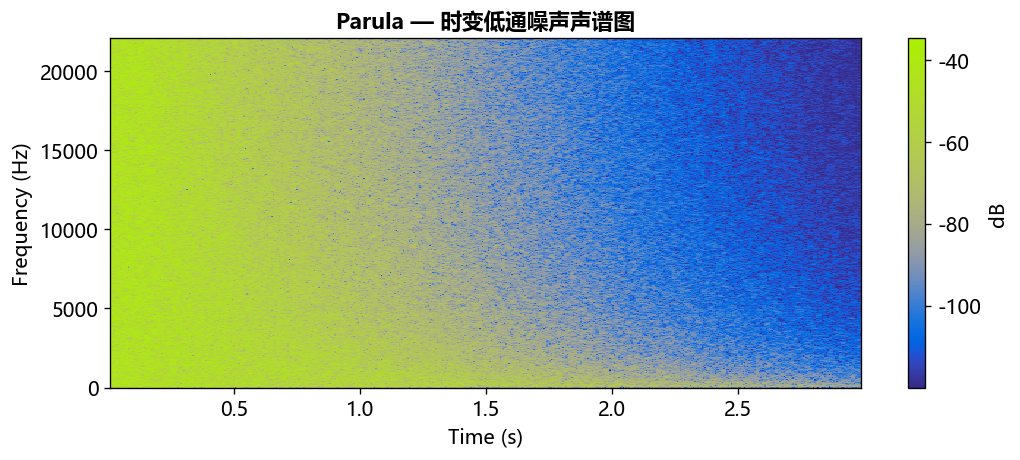

In [2]:
# Parula — 时变低通噪声声谱图
parula_colors = np.array([
    [0.2081, 0.1663, 0.5292],
    [0.2116, 0.1898, 0.5777],
    [0.2123, 0.2138, 0.6270],
    [0.2081, 0.2386, 0.6771],
    [0.1959, 0.2645, 0.7279],
    [0.1707, 0.2919, 0.7792],
    [0.1253, 0.3242, 0.8303],
    [0.0591, 0.3598, 0.8683],
    [0.0117, 0.3875, 0.8820],
    [0.0160, 0.4058, 0.8828],
    [0.0328, 0.4217, 0.8793],
    [0.0594, 0.4365, 0.8734],
    [0.0930, 0.4506, 0.8654],
    [0.1319, 0.4643, 0.8556],
    [0.1745, 0.4777, 0.8440],
    [0.2194, 0.4909, 0.8306],
    [0.2651, 0.5039, 0.8155],
    [0.3105, 0.5168, 0.7988],
    [0.3547, 0.5296, 0.7808],
    [0.3968, 0.5424, 0.7617],
    [0.4362, 0.5551, 0.7417],
    [0.4724, 0.5678, 0.7209],
    [0.5052, 0.5804, 0.6996],
    [0.5344, 0.5929, 0.6779],
    [0.5602, 0.6053, 0.6560],
    [0.5827, 0.6175, 0.6342],
    [0.6022, 0.6296, 0.6126],
    [0.6190, 0.6415, 0.5913],
    [0.6334, 0.6532, 0.5704],
    [0.6456, 0.6646, 0.5499],
    [0.6559, 0.6758, 0.5298],
    [0.6645, 0.6867, 0.5102],
    [0.6717, 0.6973, 0.4910],
    [0.6776, 0.7076, 0.4723],
    [0.6825, 0.7176, 0.4540],
    [0.6865, 0.7273, 0.4361],
    [0.6897, 0.7367, 0.4186],
    [0.6922, 0.7458, 0.4015],
    [0.6942, 0.7547, 0.3847],
    [0.6957, 0.7633, 0.3682],
    [0.6968, 0.7717, 0.3520],
    [0.6976, 0.7799, 0.3361],
    [0.6980, 0.7879, 0.3204],
    [0.6982, 0.7957, 0.3050],
    [0.6982, 0.8034, 0.2898],
    [0.6979, 0.8110, 0.2748],
    [0.6975, 0.8185, 0.2600],
    [0.6969, 0.8259, 0.2453],
    [0.6962, 0.8332, 0.2307],
    [0.6954, 0.8405, 0.2162],
    [0.6944, 0.8477, 0.2018],
    [0.6933, 0.8549, 0.1874],
    [0.6921, 0.8620, 0.1730],
    [0.6908, 0.8692, 0.1586],
    [0.6894, 0.8763, 0.1441],
    [0.6879, 0.8834, 0.1295],
    [0.6863, 0.8906, 0.1148],
    [0.6846, 0.8977, 0.0999],
    [0.6828, 0.9049, 0.0848],
    [0.6809, 0.9121, 0.0694],
    [0.6789, 0.9193, 0.0536],
    [0.6768, 0.9266, 0.0373],
    [0.6746, 0.9339, 0.0203],
    [0.6723, 0.9413, 0.0022],
])
parula_cmap = LinearSegmentedColormap.from_list("parula", parula_colors, N=256)

fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
              shading="auto", cmap=parula_cmap)
ax.set_ylim(0, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Parula — 时变低通噪声声谱图", fontsize=13, fontweight="bold")
fig.colorbar(ax.collections[0], ax=ax, label="dB")
plt.tight_layout()
plt.show()

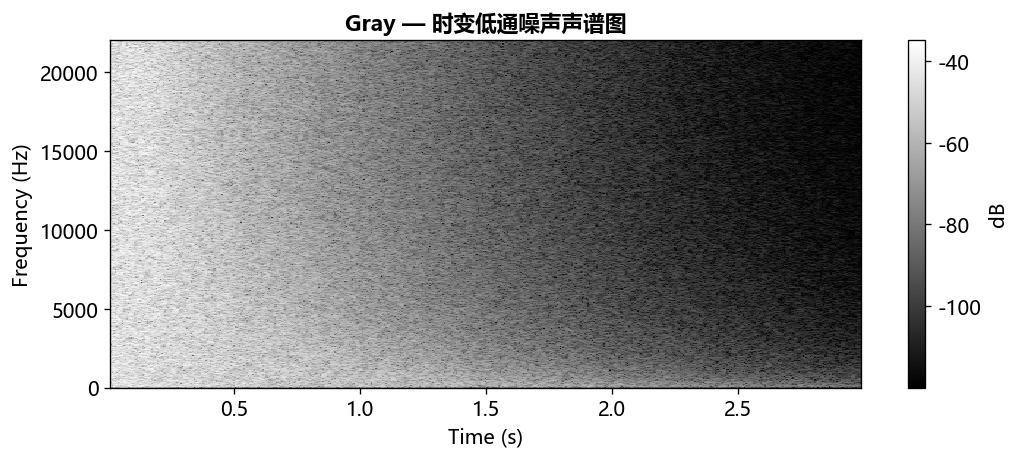

In [3]:
# Gray — 时变低通噪声声谱图
fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
              shading="auto", cmap="gray")
ax.set_ylim(0, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Gray — 时变低通噪声声谱图", fontsize=13, fontweight="bold")
fig.colorbar(ax.collections[0], ax=ax, label="dB")
plt.tight_layout()
plt.show()

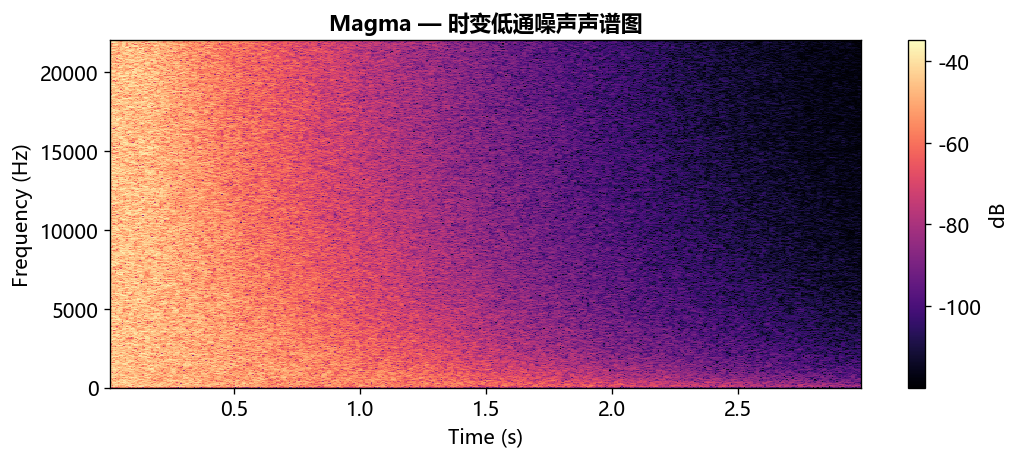

In [4]:
# Magma — 时变低通噪声声谱图
fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
              shading="auto", cmap="magma")
ax.set_ylim(0, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Magma — 时变低通噪声声谱图", fontsize=13, fontweight="bold")
fig.colorbar(ax.collections[0], ax=ax, label="dB")
plt.tight_layout()
plt.show()

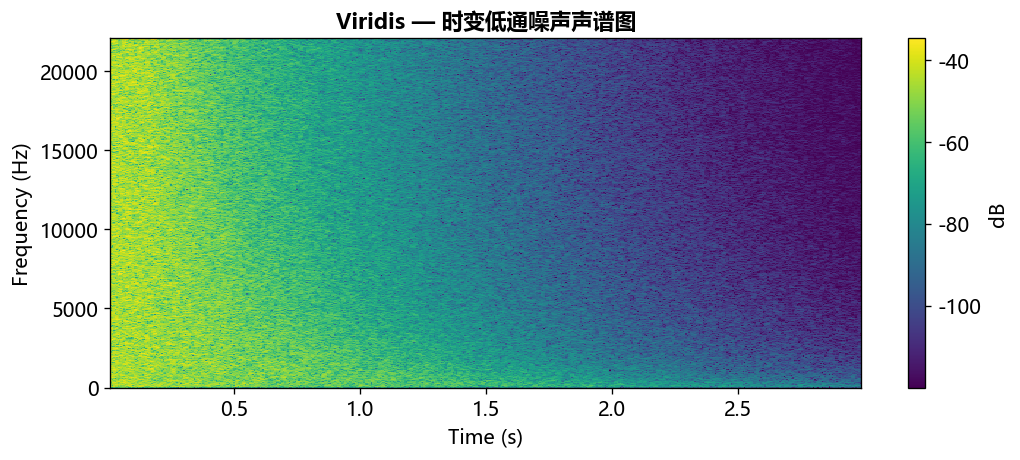

In [5]:
# Viridis — 时变低通噪声声谱图
fig, ax = plt.subplots(figsize=(9, 4))
ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
              shading="auto", cmap="viridis")
ax.set_ylim(0, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Viridis — 时变低通噪声声谱图", fontsize=13, fontweight="bold")
fig.colorbar(ax.collections[0], ax=ax, label="dB")
plt.tight_layout()
plt.show()